In [4]:
words = open("/Users/raghav/Downloads/names.txt",'r').read().splitlines()

In [5]:
print(len(words))

32033


In [7]:
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [13]:
min(len(w) for w in words)

2

In [14]:
max(len(w) for w in words)

15

In [15]:
chars = sorted(set(''.join(words)))
chars

['a',
 'b',
 'c',
 'd',
 'e',
 'f',
 'g',
 'h',
 'i',
 'j',
 'k',
 'l',
 'm',
 'n',
 'o',
 'p',
 'q',
 'r',
 's',
 't',
 'u',
 'v',
 'w',
 'x',
 'y',
 'z']

In [18]:
stoi = {s:i + 1 for i,s in enumerate(chars)}
stoi['.'] = 0
stoi

{'a': 1,
 'b': 2,
 'c': 3,
 'd': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'o': 15,
 'p': 16,
 'q': 17,
 'r': 18,
 's': 19,
 't': 20,
 'u': 21,
 'v': 22,
 'w': 23,
 'x': 24,
 'y': 25,
 'z': 26,
 '.': 0}

In [21]:
itos = {val:key for key,val in stoi.items()}
itos

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

In [31]:
import torch

In [33]:
N = torch.zeros((27,27),dtype = torch.int32)

for word in words:
    chs = ['.'] + list(word) + ['.']
    for ch1, ch2 in zip(chs,chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1,ix2] += 1

N

tensor([[   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
         1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
          134,  535,  929],
        [6640,  556,  541,  470, 1042,  692,  134,  168, 2332, 1650,  175,  568,
         2528, 1634, 5438,   63,   82,   60, 3264, 1118,  687,  381,  834,  161,
          182, 2050,  435],
        [ 114,  321,   38,    1,   65,  655,    0,    0,   41,  217,    1,    0,
          103,    0,    4,  105,    0,    0,  842,    8,    2,   45,    0,    0,
            0,   83,    0],
        [  97,  815,    0,   42,    1,  551,    0,    2,  664,  271,    3,  316,
          116,    0,    0,  380,    1,   11,   76,    5,   35,   35,    0,    0,
            3,  104,    4],
        [ 516, 1303,    1,    3,  149, 1283,    5,   25,  118,  674,    9,    3,
           60,   30,   31,  378,    0,    1,  424,   29,    4,   92,   17,   23,
            0,  317,    1],
        [3983,  679,  121,  153,  384, 1271,   82,

In [35]:
N.shape

torch.Size([27, 27])

In [38]:
import matplotlib.pyplot as plt
%matplotlib inline

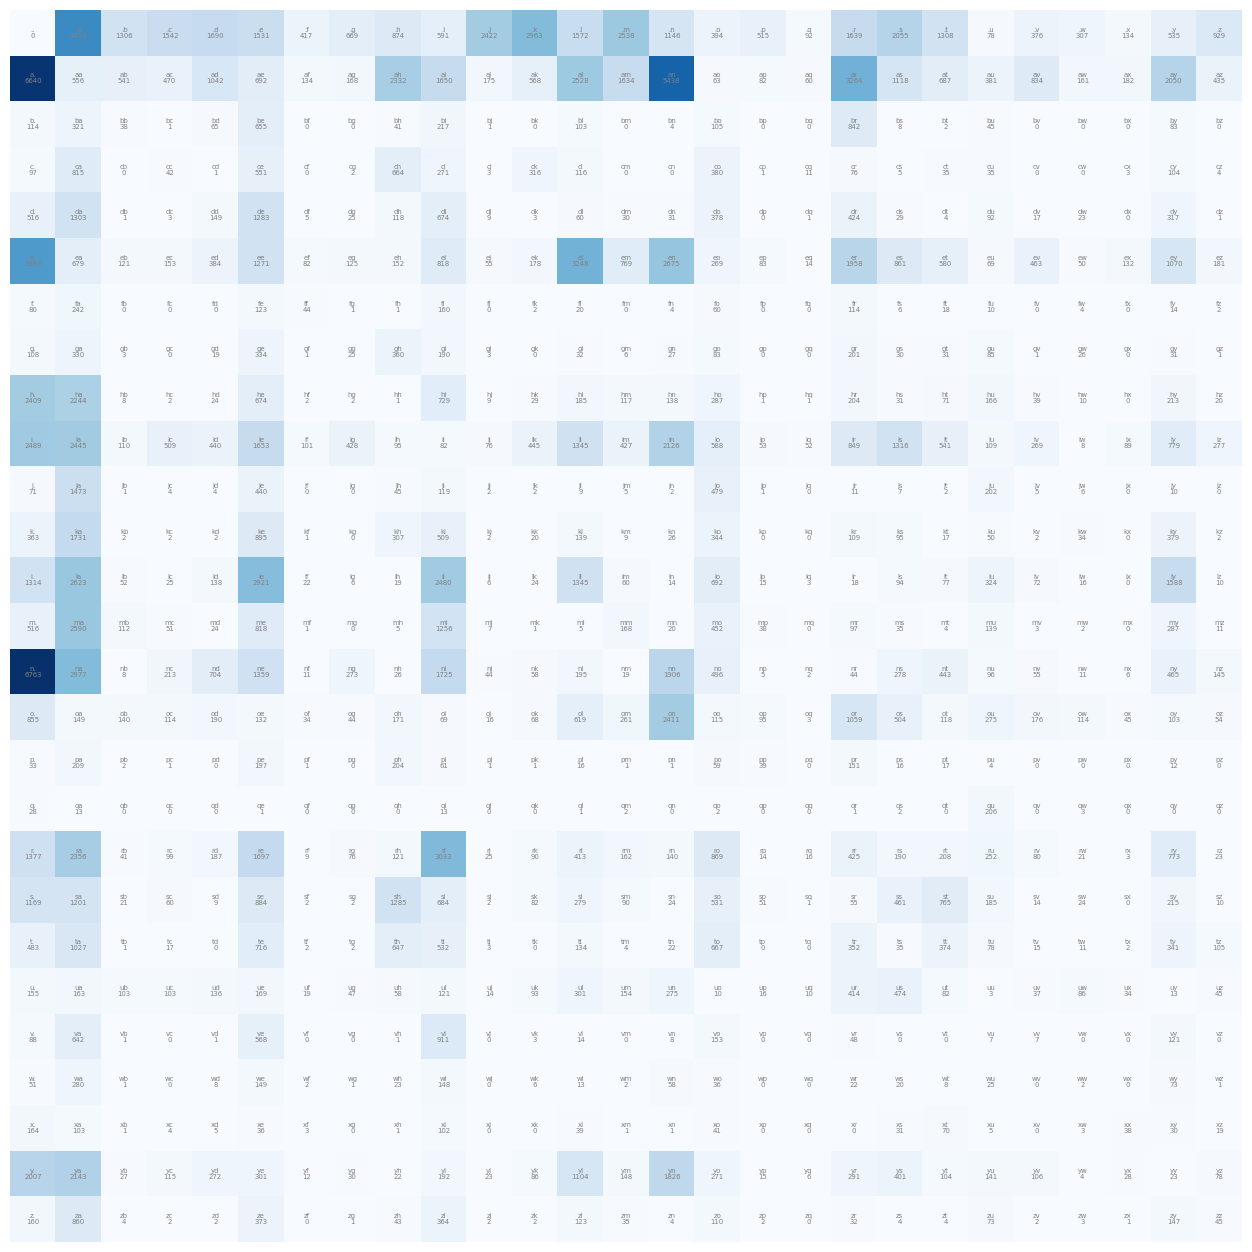

In [39]:
plt.figure(figsize=(16, 16))
plt.imshow(N, cmap='Blues')

for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha='center', va='bottom', color='gray', fontsize=5)
        plt.text(j, i, N[i, j].item(), ha='center', va='top', color='gray', fontsize=5)

plt.axis('off')
plt.show()

In [43]:
N[0]

tensor([   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
        1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
         134,  535,  929], dtype=torch.int32)

In [45]:
P = (N+1).float()
P

tensor([[1.0000e+00, 4.4110e+03, 1.3070e+03, 1.5430e+03, 1.6910e+03, 1.5320e+03,
         4.1800e+02, 6.7000e+02, 8.7500e+02, 5.9200e+02, 2.4230e+03, 2.9640e+03,
         1.5730e+03, 2.5390e+03, 1.1470e+03, 3.9500e+02, 5.1600e+02, 9.3000e+01,
         1.6400e+03, 2.0560e+03, 1.3090e+03, 7.9000e+01, 3.7700e+02, 3.0800e+02,
         1.3500e+02, 5.3600e+02, 9.3000e+02],
        [6.6410e+03, 5.5700e+02, 5.4200e+02, 4.7100e+02, 1.0430e+03, 6.9300e+02,
         1.3500e+02, 1.6900e+02, 2.3330e+03, 1.6510e+03, 1.7600e+02, 5.6900e+02,
         2.5290e+03, 1.6350e+03, 5.4390e+03, 6.4000e+01, 8.3000e+01, 6.1000e+01,
         3.2650e+03, 1.1190e+03, 6.8800e+02, 3.8200e+02, 8.3500e+02, 1.6200e+02,
         1.8300e+02, 2.0510e+03, 4.3600e+02],
        [1.1500e+02, 3.2200e+02, 3.9000e+01, 2.0000e+00, 6.6000e+01, 6.5600e+02,
         1.0000e+00, 1.0000e+00, 4.2000e+01, 2.1800e+02, 2.0000e+00, 1.0000e+00,
         1.0400e+02, 1.0000e+00, 5.0000e+00, 1.0600e+02, 1.0000e+00, 1.0000e+00,
         8.4300e+

In [46]:
P = P / P.sum(1,keepdim=True)

In [47]:
P[0].sum()

tensor(1.)

In [48]:
P[5].sum()

tensor(1.)

In [49]:
P.shape

torch.Size([27, 27])

In [51]:
g = torch.Generator().manual_seed(2147483647)

ix = 0 
name = []

while True:
    p = P[ix]
    ix = torch.multinomial(p,num_samples=1,replacement=True,generator=g).item()
    if ix == 0:
        break
    name.append(itos[ix])

print(''.join(name))

cexze


In [53]:
g = torch.Generator().manual_seed(2147483647)

for i in range(20):
    ix = 0 
    name = []
    
    while True:
        p = P[ix]
        ix = torch.multinomial(p,num_samples=1,replacement=True,generator=g).item()
        if ix == 0:
            break
        name.append(itos[ix])
    
    print(''.join(name))

cexze
momasurailezitynn
konimittain
llayn
ka
da
staiyaubrtthrigotai
moliellavo
ke
teda
ka
emimmsade
enkaviyny
ftlspihinivenvorhlasu
dsor
br
jol
pen
aisan
ja


In [55]:
log_likelihood = 0
n = 0

for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        log_likelihood += torch.log(prob).item()
        n += 1

nll = -log_likelihood / n
print(f'log likelihood: {log_likelihood:.4f}')
print(f'total bigrams:  {n}')
print(f'NLL loss:       {nll:.4f}')

log likelihood: -560001.8847
total bigrams:  228146
NLL loss:       2.4546


In [56]:
uniform_loss = -torch.log(torch.tensor(1/27)).item()
print(f'Uniform baseline loss: {uniform_loss:.4f}')
print(f'Our model loss:        {nll:.4f}')
print(f'Our model is better by: {uniform_loss - nll:.4f}')

Uniform baseline loss: 3.2958
Our model loss:        2.4546
Our model is better by: 0.8413


In [60]:
#Building training dataset

xs = []
ys = []
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1,ch2 in zip(chs,chs[1:]):
        xs.append(stoi[ch1])
        ys.append(stoi[ch2])

xs = torch.tensor(xs)
ys = torch.tensor(ys)

print(f'inputs  xs: {xs.shape}')
print(f'targets ys: {ys.shape}')
print(f'first 5 pairs: {list(zip(xs[:5].tolist(), ys[:5].tolist()))}')

inputs  xs: torch.Size([228146])
targets ys: torch.Size([228146])
first 5 pairs: [(0, 5), (5, 13), (13, 13), (13, 1), (1, 0)]


In [61]:
xs

tensor([ 0,  5, 13,  ..., 25, 26, 24])

In [62]:
ys

tensor([ 5, 13, 13,  ..., 26, 24,  0])

In [63]:
import torch.nn.functional as F

In [67]:
xenc = F.one_hot(xs,num_classes = 27).float()

g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)

print(f'xenc shape: {xenc.shape}')
print(f'W shape:    {W.shape}')
print(f'xenc[0]:    {xenc[0]}')

xenc shape: torch.Size([228146, 27])
W shape:    torch.Size([27, 27])
xenc[0]:    tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0.])


In [69]:
logits = xenc @ W
counts = logits.exp()
probs = counts / counts.sum(1, keepdim=True)

loss = -probs[torch.arange(len(xs)), ys].log().mean()
print(f'loss before training: {loss.item():.4f}')

loss before training: 3.7590


In [70]:
probs

tensor([[0.0607, 0.0100, 0.0123,  ..., 0.0118, 0.1537, 0.1459],
        [0.0290, 0.0796, 0.0248,  ..., 0.0118, 0.0022, 0.0472],
        [0.0312, 0.0737, 0.0484,  ..., 0.1204, 0.0469, 0.0126],
        ...,
        [0.0301, 0.0080, 0.0090,  ..., 0.0125, 0.0531, 0.0111],
        [0.0634, 0.0270, 0.0101,  ..., 0.0833, 0.0175, 0.0517],
        [0.0308, 0.0113, 0.0178,  ..., 0.0190, 0.0116, 0.0562]],
       grad_fn=<DivBackward0>)

In [71]:
probs.shape

torch.Size([228146, 27])

In [74]:
# manually check first 3 rows
for i in range(3):
    print(f'row {i}: correct char = {itos[ys[i].item()]!r}, prob = {probs[i, ys[i]].item():.4f}')

row 0: correct char = 'e', prob = 0.0123
row 1: correct char = 'm', prob = 0.0181
row 2: correct char = 'm', prob = 0.0267


In [77]:
#training looop
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)

xenc = F.one_hot(xs,num_classes=27).float()

for k in range(200):

    logits = xenc @ W
    counts = logits.exp()
    probs = counts / counts.sum(1,keepdim=True)
    loss   = -probs[torch.arange(len(xs)), ys].log().mean()
    loss += 0.01 * (W**2).mean()

    W.grad = None
    loss.backward()

    W.data += -50 * W.grad

In [79]:
print(f'final loss: {loss.item():.4f}')

final loss: 2.4830


In [82]:
g = torch.Generator().manual_seed(2147483647)

for _ in range(20):
    name = []
    ix = 0
    while True:
        xenc = F.one_hot(torch.tensor([ix]), num_classes=27).float()
        probs = (xenc @ W).exp()
        probs = probs / probs.sum()
        ix = torch.multinomial(probs, num_samples=1, replacement=True, generator=g).item()
        if ix == 0:
            break
        name.append(itos[ix])
    print(''.join(name))

cexze
momasurailezityha
konimittain
llayn
ka
da
staiyaubrtthrigotai
moliellavo
ke
teda
ka
emimmsade
enkaviyny
fobspehinivenvtahlasu
dsor
br
jol
pyawaisan
ja
fdinee
